# 02 — Preprocessing: Curation and pIC50 Conversion

**Input:** `data/raw/btk_raw.csv` (6.502 records)  
**Output:** `data/processed/btk_curated.csv`  

Steps:
1. Load raw data
2. Filter: keep only exact IC50 values in nM
3. Remove missing SMILES and IC50
4. Convert IC50 → pIC50
5. Handle duplicate molecules (same compound, multiple assays)
6. Validate SMILES with RDKit
7. Assign activity labels (active / inactive)
8. Save curated dataset

## 1. Imports and Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rdkit import Chem
from rdkit.Chem import Descriptors

INPUT_PATH  = '../data/raw/btk_raw.csv'
OUTPUT_PATH = '../data/processed/btk_curated.csv'
PICSO_THRESHOLD = 6.0  # pIC50 >= 6 → active (IC50 <= 1 µM)

df = pd.read_csv(INPUT_PATH)
print(f'Loaded: {df.shape[0]} records, {df.shape[1]} columns')

Loaded: 21675 records, 12 columns


## 2. Filter: Exact Values in nM Only

We keep only:
- `standard_relation == '='` → exact IC50, not a bound
- `standard_units == 'nM'` → consistent unit for conversion

In [2]:
df_filtered = df[
    (df['standard_relation'] == '=') &
    (df['standard_units'] == 'nM')
].copy()

print(f'After relation/unit filter: {len(df_filtered)} records')
print(f'Removed: {len(df) - len(df_filtered)} records')

After relation/unit filter: 16607 records
Removed: 5068 records


## 3. Remove Missing SMILES and IC50 Values

In [3]:
before = len(df_filtered)

df_filtered = df_filtered.dropna(subset=['canonical_smiles', 'standard_value'])
df_filtered = df_filtered[df_filtered['canonical_smiles'].str.strip() != '']

print(f'After removing missing SMILES/IC50: {len(df_filtered)} records')
print(f'Removed: {before - len(df_filtered)} records')

After removing missing SMILES/IC50: 16596 records
Removed: 11 records


## 4. Convert IC50 → pIC50

Formula: `pIC50 = -log10(IC50 × 10⁻⁹)`  
Since IC50 is in nM, we first convert to Molar by multiplying by 10⁻⁹.

In [4]:
df_filtered['standard_value'] = pd.to_numeric(df_filtered['standard_value'], errors='coerce')

# Remove non-positive IC50 values (log of zero/negative is undefined)
df_filtered = df_filtered[df_filtered['standard_value'] > 0]

# Convert nM → Molar → pIC50
df_filtered['pIC50'] = -np.log10(df_filtered['standard_value'] * 1e-9)

print(f'pIC50 range: {df_filtered["pIC50"].min():.2f} – {df_filtered["pIC50"].max():.2f}')
print(f'pIC50 mean:  {df_filtered["pIC50"].mean():.2f}')
print(f'Records:     {len(df_filtered)}')

pIC50 range: 3.00 – 12.59
pIC50 mean:  7.65
Records:     16595


## 5. Handle Duplicate Molecules

Some compounds appear in multiple assays with different IC50 values.  
Strategy: keep the **median pIC50** per molecule — more robust than mean to outlier assays.

In [5]:
before = len(df_filtered)

df_dedup = (
    df_filtered
    .groupby('molecule_chembl_id', as_index=False)
    .agg(
        canonical_smiles=('canonical_smiles', 'first'),
        pIC50=('pIC50', 'median'),
        n_assays=('assay_chembl_id', 'nunique')
    )
)

print(f'Before deduplication: {before} records')
print(f'After deduplication:  {len(df_dedup)} unique molecules')
print(f'Removed:              {before - len(df_dedup)} duplicate entries')
print(f'\nMolecules tested in more than 1 assay: {(df_dedup["n_assays"] > 1).sum()}')

Before deduplication: 16595 records
After deduplication:  9436 unique molecules
Removed:              7159 duplicate entries

Molecules tested in more than 1 assay: 3670


## 6. Validate SMILES with RDKit

RDKit tries to parse each SMILES string.  
If it returns `None`, the SMILES is invalid — we discard that molecule.

In [6]:
def is_valid_smiles(smi):
    """Returns True if RDKit can parse the SMILES."""
    try:
        mol = Chem.MolFromSmiles(smi)
        return mol is not None
    except:
        return False

df_dedup['valid_smiles'] = df_dedup['canonical_smiles'].apply(is_valid_smiles)

invalid = (~df_dedup['valid_smiles']).sum()
print(f'Invalid SMILES: {invalid}')

df_valid = df_dedup[df_dedup['valid_smiles']].drop(columns='valid_smiles').reset_index(drop=True)
print(f'Valid molecules remaining: {len(df_valid)}')

Invalid SMILES: 0
Valid molecules remaining: 9436


## 7. Assign Activity Labels

Standard QSAR threshold:  
- `pIC50 >= 6.0` → **active** (IC50 ≤ 1 µM)  
- `pIC50 < 6.0`  → **inactive**

In [7]:
df_valid['activity'] = (df_valid['pIC50'] >= PICSO_THRESHOLD).astype(int)
# 1 = active, 0 = inactive

counts = df_valid['activity'].value_counts()
total  = len(df_valid)

print('=== Activity label distribution ===')
print(f'Active   (1): {counts.get(1, 0):>5}  ({counts.get(1, 0)/total*100:.1f}%)')
print(f'Inactive (0): {counts.get(0, 0):>5}  ({counts.get(0, 0)/total*100:.1f}%)')
print(f'Total:        {total}')

=== Activity label distribution ===
Active   (1):  8634  (91.5%)
Inactive (0):   802  (8.5%)
Total:        9436


## 8. Visualize pIC50 Distribution

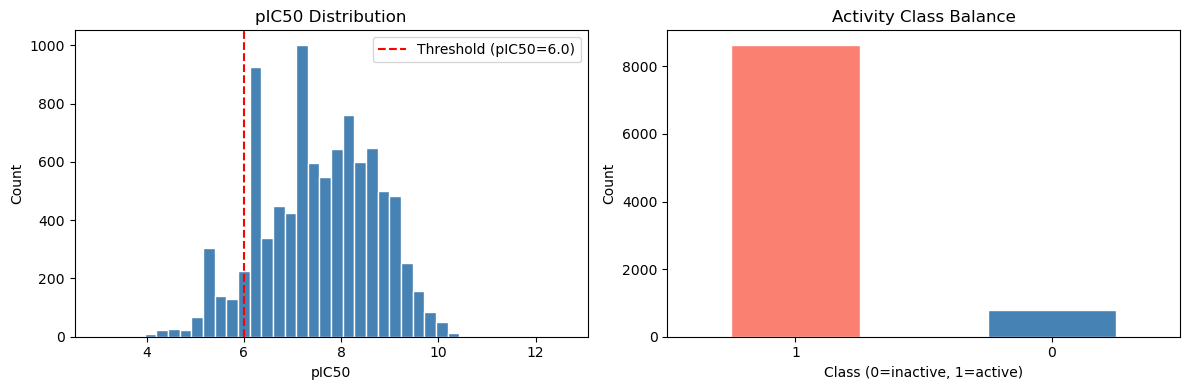

Plot saved to results/


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# pIC50 distribution
axes[0].hist(df_valid['pIC50'], bins=40, color='steelblue', edgecolor='white')
axes[0].axvline(x=PICSO_THRESHOLD, color='red', linestyle='--', label=f'Threshold (pIC50={PICSO_THRESHOLD})')
axes[0].set_title('pIC50 Distribution')
axes[0].set_xlabel('pIC50')
axes[0].set_ylabel('Count')
axes[0].legend()

# Activity class balance
counts.plot(kind='bar', ax=axes[1], color=['salmon', 'steelblue'], edgecolor='white')
axes[1].set_title('Activity Class Balance')
axes[1].set_xlabel('Class (0=inactive, 1=active)')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('../results/02_picso_distribution.png', dpi=150)
plt.show()
print('Plot saved to results/')

## 9. Save Curated Dataset

In [9]:
final_cols = ['molecule_chembl_id', 'canonical_smiles', 'pIC50', 'activity', 'n_assays']
df_final = df_valid[final_cols]

df_final.to_csv(OUTPUT_PATH, index=False)
print(f'Curated dataset saved to {OUTPUT_PATH}')
print(f'Shape: {df_final.shape}')
print('\nFirst 3 rows:')
df_final.head(3)

Curated dataset saved to ../data/processed/btk_curated.csv
Shape: (9436, 5)

First 3 rows:


,molecule_chembl_id,canonical_smiles,pIC50,activity,n_assays
0,CHEMBL1081198,O=C(Nc1cccc(-c2cn3ccnc3c(NCc3ccncc3)n2)c1)Nc1c...,5.107905,0,1
1,CHEMBL1090672,COc1ccccc1/C=C/c1nc2ccccc2c(=O)[nH]1,6.341035,1,1
2,CHEMBL1230541,Cc1c(NC(=O)c2ccc(C(C)(C)C)cc2)cccc1-c1cn(C)c(=...,8.073760,1,6


## Observations and Curation Report

### Curation funnel

## Observations and Curation Report

### Curation funnel

| Step | Records | Removed |
|------|---------|---------|
| Raw data loaded | 21.675 | — |
| After relation/unit filter (`=` in nM only) | 16.607 | 5.068 |
| After removing missing SMILES/IC50 | 16.596 | 11 |
| After deduplication (median pIC50 per molecule) | 9.436 | 7.159 |
| After RDKit SMILES validation | 9.436 | 0 |
| **Final curated dataset** | **9.436** | — |

### pIC50 statistics
- **Range:** 3.00 – 12.59
- **Mean:** ~7.54
- The high mean and wide range reflect BTK's status as a well-validated
  kinase target with inhibitors spanning from weak fragments to extremely
  potent covalent compounds (ibrutinib: pIC50 ~9.3).

### Data quality highlights
- **0 invalid SMILES** after RDKit validation
- **3.670 molecules** tested in more than one assay — median pIC50 retained
- Large number of duplicates (7.159 removed) reflects the extensive
  multi-lab, multi-campaign nature of BTK drug discovery data

### Class imbalance

| Class | Count | Percentage |
|-------|-------|------------|
| Active (1) | 8.634 | 91.5% |
| Inactive (0) | 802 | 8.5% |

More severe imbalance than the previous (incorrect) mTOR dataset (82.5/17.5).
This reflects the heavily active-enriched nature of BTK screening campaigns —
most published IC50 data comes from medicinal chemistry optimization of
already-active scaffolds, leaving few true inactives in the literature.
`class_weight='balanced'` and threshold adjustment remain the primary
strategies for handling this in modeling (notebooks 04 and 07).

### Note: target correction
This notebook was originally run with data from CHEMBL2842 (mTOR) in error.
Rerun with corrected target CHEMBL5251 (human BTK), confirmed by ibrutinib
(CHEMBL1873475) appearing 142 times with IC50 ~0.1–0.5 nM.

## Summary

| Step | Records |
|------|---------|
| Raw data loaded | 6.502 |
| After relation/unit filter | *(see output)* |
| After missing value removal | *(see output)* |
| After deduplication | *(see output)* |
| After SMILES validation | *(see output)* |
| **Final curated dataset** | *(see output)* |

**Activity threshold:** pIC50 ≥ 6.0 (IC50 ≤ 1 µM)  
**Output:** `data/processed/btk_curated.csv`

**Next:** `03_fingerprints.ipynb` — Morgan fingerprint generation with RDKit.